# House Rent Price Prediction using Artificial Neural Networks (PyTorch)

In [1]:
import pandas as pd

## Load Dataset

In [2]:
pune=pd.read_csv("Indian_housing_Pune_data.csv")

In [3]:
delhi=pd.read_csv("Indian_housing_Delhi_data.csv")

In [4]:
mumbai=pd.read_csv("Indian_housing_Mumbai_data.csv")

In [5]:
pune.head()

,house_type,house_size,location,city,latitude,longitude,price,currency,numBathrooms,numBalconies,isNegotiable,priceSqFt,verificationDate,description,SecurityDeposit,Status
0,2 BHK Apartment,906 sq ft,Lohegaon,Pune,18.605820,73.912407,12000,INR,2.0,NaN,NaN,NaN,Posted 3 years ago,A spacious 2 bhk multistorey apartment is avai...,No Deposit,Unfurnished
1,1 BHK Apartment,650 sq ft,Anand Nagar,Pune,18.474377,73.820549,11000,INR,1.0,NaN,NaN,NaN,Posted 2 years ago,It has a built-up area of 650 sqft and is avai...,No Deposit,Semi-Furnished
2,1 RK Studio Apartment,350 sq ft,Wagholi,Pune,18.580336,73.980507,4500,INR,1.0,NaN,NaN,NaN,Posted 2 years ago,This spacious 1 rk independent house is availa...,No Deposit,Unfurnished
3,3 BHK Apartment,"1,500 sq ft",Sangamvadi,Pune,18.541786,73.882454,35000,INR,2.0,NaN,NaN,NaN,Posted 3 years ago,"Furnishings include 1 tv, 1 refrigerator, 1 so...",No Deposit,Furnished
4,5 BHK Independent House,"5,000 sq ft",Wadgaon Sheri,Pune,18.560164,73.924927,110000,INR,5.0,NaN,NaN,NaN,Posted 3 years ago,Itâs a 5 bhk independent house situated in W...,No Deposit,Unfurnished


In [6]:
delhi.head()

,house_type,house_size,location,city,latitude,longitude,price,currency,numBathrooms,numBalconies,isNegotiable,priceSqFt,verificationDate,description,SecurityDeposit,Status
0,1 RK Studio Apartment,400 sq ft,Kalkaji,Delhi,28.545561,77.254349,22000,INR,1.0,NaN,NaN,NaN,Posted a day ago,"Fully furnished, loaded with amenities & gadge...",No Deposit,Furnished
1,1 RK Studio Apartment,400 sq ft,Mansarover Garden,Delhi,28.643259,77.132828,20000,INR,1.0,NaN,NaN,NaN,Posted 9 days ago,Here is an excellent 1 BHK Independent Floor a...,No Deposit,Furnished
2,2 BHK Independent Floor,500 sq ft,Uttam Nagar,Delhi,28.618677,77.053352,8500,INR,1.0,NaN,NaN,NaN,Posted 12 days ago,"Zero Brokerage.\n\n2 Room set, Govt bijali Met...",No Deposit,Semi-Furnished
3,3 BHK Independent House,"1,020 sq ft",Model Town,Delhi,28.712898,77.180000,48000,INR,3.0,NaN,NaN,NaN,Posted a year ago,Itâs a 3 bhk independent house situated in M...,No Deposit,Furnished
4,2 BHK Apartment,810 sq ft,Sector 13 Rohini,Delhi,28.723539,77.131424,20000,INR,2.0,NaN,NaN,NaN,Posted a year ago,Well designed 2 bhk multistorey apartment is a...,No Deposit,Unfurnished


In [7]:
mumbai.head()

,house_type,house_size,location,city,latitude,longitude,price,currency,numBathrooms,numBalconies,isNegotiable,priceSqFt,verificationDate,description,SecurityDeposit,Status
0,2 BHK Apartment,"1,180 sq ft",Ulwe,Mumbai,18.971046,73.017723,19000,INR,2.0,NaN,NaN,NaN,Posted 2 years ago,It has area of 1180 sqft and is available at a...,No Deposit,Furnished
1,2 BHK Apartment,"1,120 sq ft",Ulwe,Mumbai,18.966377,73.012802,12500,INR,2.0,NaN,NaN,NaN,Posted 2 years ago,Well designed 2 bhk multistorey apartment is a...,No Deposit,Unfurnished
2,2 BHK Apartment,"1,200 sq ft",Panvel,Mumbai,18.965979,73.124649,22000,INR,2.0,NaN,NaN,NaN,Posted a month ago,A spacious 2 bhk multistorey apartment is avai...,No Deposit,Unfurnished
3,2 BHK Apartment,750 sq ft,Kandivali West,Mumbai,19.213598,72.833633,28500,INR,2.0,NaN,NaN,NaN,Posted 3 years ago,It has a built-up area of 750 sqft and is avai...,No Deposit,Unfurnished
4,3 BHK Apartment,"1,400 sq ft",Chembur,Mumbai,19.062933,72.892395,50000,INR,3.0,NaN,NaN,NaN,Posted 3 years ago,The house is semi-furnished. It has power back...,No Deposit,Semi-Furnished


In [8]:
print(pune.columns.equals(delhi.columns))
print(pune.columns.equals(mumbai.columns))

True
True


In [9]:
df_raw=pd.concat([delhi,pune,mumbai],ignore_index=True)

##  Data Cleaning
- Missing Values
- Duplicate Values
- Outlier Analysis

In [10]:
df_raw.isnull().sum()

house_type              0
house_size              0
location                0
city                    0
latitude                0
longitude               0
price                   0
currency                0
numBathrooms           56
numBalconies         8619
isNegotiable        12634
priceSqFt           13910
verificationDate        0
description           831
SecurityDeposit         0
Status                  0
dtype: int64

In [11]:
df_raw.duplicated().sum()

np.int64(1063)

In [12]:
duplicates=df_raw[df_raw.duplicated()]

In [13]:
duplicates.head(2)

,house_type,house_size,location,city,latitude,longitude,price,currency,numBathrooms,numBalconies,isNegotiable,priceSqFt,verificationDate,description,SecurityDeposit,Status
138,2 BHK Independent Floor,630 sq ft,Dashrath Puri,Delhi,28.606684,77.082848,13000,INR,2.0,NaN,NaN,NaN,Posted a month ago,This is a well-designed 2 BHK Independent Floo...,No Deposit,Semi-Furnished
158,2 BHK Independent Floor,816 sq ft,Janakpuri,Delhi,28.621193,77.091026,32000,INR,2.0,NaN,NaN,NaN,Posted a month ago,Well designed 2 bhk builder floor is available...,No Deposit,Semi-Furnished


In [14]:
duplicates.shape

(1063, 16)

In [15]:
duplicates = df_raw[df_raw.duplicated(keep=False)]
duplicates.head(10)

,house_type,house_size,location,city,latitude,longitude,price,currency,numBathrooms,numBalconies,isNegotiable,priceSqFt,verificationDate,description,SecurityDeposit,Status
91,1 BHK Apartment,600 sq ft,SULTANPUR,Delhi,28.495438,77.161774,14000,INR,1.0,NaN,NaN,NaN,Posted a month ago,This spacious 1 bhk multistorey apartment is a...,No Deposit,Unfurnished
92,3 BHK Apartment,"1,900 sq ft",Sector 11 Dwarka,Delhi,28.589540,77.049995,45000,INR,3.0,NaN,NaN,NaN,Posted a month ago,This spacious 3 bhk multistorey apartment is a...,No Deposit,Semi-Furnished
95,1 RK Studio Apartment,360 sq ft,Karampura,Delhi,28.665760,77.150230,22000,INR,1.0,NaN,NaN,NaN,Posted a month ago,A spacious 1 rk multistorey apartment is avail...,No Deposit,Furnished
137,2 BHK Independent Floor,630 sq ft,Dashrath Puri,Delhi,28.606684,77.082848,13000,INR,2.0,NaN,NaN,NaN,Posted a month ago,This is a well-designed 2 BHK Independent Floo...,No Deposit,Semi-Furnished
138,2 BHK Independent Floor,630 sq ft,Dashrath Puri,Delhi,28.606684,77.082848,13000,INR,2.0,NaN,NaN,NaN,Posted a month ago,This is a well-designed 2 BHK Independent Floo...,No Deposit,Semi-Furnished
157,2 BHK Independent Floor,816 sq ft,Janakpuri,Delhi,28.621193,77.091026,32000,INR,2.0,NaN,NaN,NaN,Posted a month ago,Well designed 2 bhk builder floor is available...,No Deposit,Semi-Furnished
158,2 BHK Independent Floor,816 sq ft,Janakpuri,Delhi,28.621193,77.091026,32000,INR,2.0,NaN,NaN,NaN,Posted a month ago,Well designed 2 bhk builder floor is available...,No Deposit,Semi-Furnished
174,4 BHK Independent Floor,"1,500 sq ft",Kalyan Vihar,Delhi,28.689827,77.194626,39000,INR,3.0,NaN,NaN,NaN,Posted 17 days ago,4BHK FLAT ON RENT IN\n CC COLONY\nNORTH CAMPUS...,No Deposit,Semi-Furnished
176,1 BHK Independent Floor,500 sq ft,Govindpuri Extension,Delhi,28.534821,77.257393,11500,INR,1.0,NaN,NaN,NaN,Posted 19 days ago,Check out this Independent Floor available for...,No Deposit,Unfurnished
177,2 BHK Apartment,"1,200 sq ft",Paschim Vihar,Delhi,28.657253,77.091988,32000,INR,2.0,NaN,NaN,NaN,Posted 17 days ago,A spacious 2 bhk multistorey apartment is avai...,No Deposit,Furnished


In [16]:
df=df_raw.drop_duplicates()

In [17]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 13910 entries, 0 to 13909
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   house_type        13910 non-null  str    
 1   house_size        13910 non-null  str    
 2   location          13910 non-null  str    
 3   city              13910 non-null  str    
 4   latitude          13910 non-null  float64
 5   longitude         13910 non-null  float64
 6   price             13910 non-null  int64  
 7   currency          13910 non-null  str    
 8   numBathrooms      13854 non-null  float64
 9   numBalconies      5291 non-null   float64
 10  isNegotiable      1276 non-null   str    
 11  priceSqFt         0 non-null      float64
 12  verificationDate  13910 non-null  str    
 13  description       13079 non-null  str    
 14  SecurityDeposit   13910 non-null  str    
 15  Status            13910 non-null  str    
dtypes: float64(5), int64(1), str(10)
memory usage: 1.7 

In [18]:
df_raw.describe()

,latitude,longitude,price,numBathrooms,numBalconies,priceSqFt
count,13910.000000,13910.000000,1.391000e+04,13854.000000,5291.000000,0.0
mean,22.380579,74.710460,1.084971e+05,2.326765,1.840484,NaN
std,4.660315,2.181421,1.934349e+05,1.002262,0.703672,NaN
min,17.468220,18.497896,1.500000e+03,1.000000,1.000000,NaN
25%,18.611296,72.965080,1.800000e+04,2.000000,1.000000,NaN
50%,19.148081,73.895599,3.300000e+04,2.000000,2.000000,NaN
75%,28.553211,77.152527,9.000000e+04,3.000000,2.000000,NaN
max,31.106586,91.792137,3.010101e+06,10.000000,8.000000,NaN


In [19]:
df_raw["house_type"].value_counts()

house_type
2 BHK Apartment              4385
1 BHK Apartment              2622
3 BHK Apartment              1837
3 BHK Independent Floor      1571
4 BHK Independent Floor       786
2 BHK Independent Floor       542
1 RK Studio Apartment         434
4 BHK Apartment               297
4 BHK Villa                   273
1 BHK Independent Floor       255
5 BHK Villa                   185
5 BHK Independent Floor       180
5 BHK Independent House       153
4 BHK Independent House       128
1 BHK Independent House        69
3 BHK Villa                    47
3 BHK Independent House        29
2 BHK Independent House        28
5 BHK Apartment                27
2 BHK Villa                    23
6 BHK Independent Floor         6
6 BHK Apartment                 6
1 BHK Villa                     5
6 BHK Villa                     5
9 BHK Independent House         3
6 BHK penthouse                 3
8 BHK Independent Floor         2
7 BHK Independent Floor         2
10 BHK Independent House        2
8 B

In [20]:
df[["BHK","TYPE"]]=df_raw["house_type"].str.extract(r"(\d+\s*(?:BHK|RK))\s+(.+)")

In [21]:
df

,house_type,house_size,location,city,latitude,longitude,price,currency,numBathrooms,numBalconies,isNegotiable,priceSqFt,verificationDate,description,SecurityDeposit,Status,BHK,TYPE
0,1 RK Studio Apartment,400 sq ft,Kalkaji,Delhi,28.545561,77.254349,22000,INR,1.0,NaN,NaN,NaN,Posted a day ago,"Fully furnished, loaded with amenities & gadge...",No Deposit,Furnished,1 RK,Studio Apartment
1,1 RK Studio Apartment,400 sq ft,Mansarover Garden,Delhi,28.643259,77.132828,20000,INR,1.0,NaN,NaN,NaN,Posted 9 days ago,Here is an excellent 1 BHK Independent Floor a...,No Deposit,Furnished,1 RK,Studio Apartment
2,2 BHK Independent Floor,500 sq ft,Uttam Nagar,Delhi,28.618677,77.053352,8500,INR,1.0,NaN,NaN,NaN,Posted 12 days ago,"Zero Brokerage.\n\n2 Room set, Govt bijali Met...",No Deposit,Semi-Furnished,2 BHK,Independent Floor
3,3 BHK Independent House,"1,020 sq ft",Model Town,Delhi,28.712898,77.180000,48000,INR,3.0,NaN,NaN,NaN,Posted a year ago,Itâs a 3 bhk independent house situated in M...,No Deposit,Furnished,3 BHK,Independent House
4,2 BHK Apartment,810 sq ft,Sector 13 Rohini,Delhi,28.723539,77.131424,20000,INR,2.0,NaN,NaN,NaN,Posted a year ago,Well designed 2 bhk multistorey apartment is a...,No Deposit,Unfurnished,2 BHK,Apartment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13905,2 BHK Apartment,800 sq ft,Saki Naka,Mumbai,19.257641,72.848587,46000,INR,2.0,NaN,NaN,NaN,Posted a year ago,Gundecha asta complex. Andheri East. sakinaka ...,"1,50,000",Unfurnished,2 BHK,Apartment
13906,2 BHK Apartment,"1,200 sq ft",Malad West,Mumbai,19.187275,72.831146,55000,INR,2.0,NaN,NaN,NaN,Posted a year ago,It has an area of 1200 sqft . The property is ...,"2,50,000",Semi-Furnished,2 BHK,Apartment
13907,2 BHK Apartment,"1,040 sq ft",Goregaon West,Mumbai,19.170622,72.844917,44000,INR,2.0,NaN,NaN,NaN,Posted a year ago,It is located on the 7th floor(out of a total ...,"2,00,000",Unfurnished,2 BHK,Apartment
13908,3 BHK Apartment,"1,930 sq ft",Kharghar,Mumbai,19.028339,73.057526,65000,INR,3.0,NaN,NaN,NaN,Posted a year ago,"It is a furnished property. It has 1 wardrobe,...","2,00,000",Furnished,3 BHK,Apartment


In [22]:
df["TYPE"].value_counts()

TYPE
Apartment             8540
Independent Floor     3047
Villa                  477
Studio Apartment       403
Independent House      378
penthouse                2
Name: count, dtype: int64

In [23]:
df["BHK"].value_counts()

BHK
2 BHK     4672
3 BHK     3189
1 BHK     2733
4 BHK     1359
5 BHK      460
1 RK       403
6 BHK       18
8 BHK        4
7 BHK        3
9 BHK        3
10 BHK       2
12 BHK       1
Name: count, dtype: int64

In [24]:
df["bedrooms"] = df["house_type"].str.extract(r"(\d+)").astype(float)

In [25]:
df

,house_type,house_size,location,city,latitude,longitude,price,currency,numBathrooms,numBalconies,isNegotiable,priceSqFt,verificationDate,description,SecurityDeposit,Status,BHK,TYPE,bedrooms
0,1 RK Studio Apartment,400 sq ft,Kalkaji,Delhi,28.545561,77.254349,22000,INR,1.0,NaN,NaN,NaN,Posted a day ago,"Fully furnished, loaded with amenities & gadge...",No Deposit,Furnished,1 RK,Studio Apartment,1.0
1,1 RK Studio Apartment,400 sq ft,Mansarover Garden,Delhi,28.643259,77.132828,20000,INR,1.0,NaN,NaN,NaN,Posted 9 days ago,Here is an excellent 1 BHK Independent Floor a...,No Deposit,Furnished,1 RK,Studio Apartment,1.0
2,2 BHK Independent Floor,500 sq ft,Uttam Nagar,Delhi,28.618677,77.053352,8500,INR,1.0,NaN,NaN,NaN,Posted 12 days ago,"Zero Brokerage.\n\n2 Room set, Govt bijali Met...",No Deposit,Semi-Furnished,2 BHK,Independent Floor,2.0
3,3 BHK Independent House,"1,020 sq ft",Model Town,Delhi,28.712898,77.180000,48000,INR,3.0,NaN,NaN,NaN,Posted a year ago,Itâs a 3 bhk independent house situated in M...,No Deposit,Furnished,3 BHK,Independent House,3.0
4,2 BHK Apartment,810 sq ft,Sector 13 Rohini,Delhi,28.723539,77.131424,20000,INR,2.0,NaN,NaN,NaN,Posted a year ago,Well designed 2 bhk multistorey apartment is a...,No Deposit,Unfurnished,2 BHK,Apartment,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13905,2 BHK Apartment,800 sq ft,Saki Naka,Mumbai,19.257641,72.848587,46000,INR,2.0,NaN,NaN,NaN,Posted a year ago,Gundecha asta complex. Andheri East. sakinaka ...,"1,50,000",Unfurnished,2 BHK,Apartment,2.0
13906,2 BHK Apartment,"1,200 sq ft",Malad West,Mumbai,19.187275,72.831146,55000,INR,2.0,NaN,NaN,NaN,Posted a year ago,It has an area of 1200 sqft . The property is ...,"2,50,000",Semi-Furnished,2 BHK,Apartment,2.0
13907,2 BHK Apartment,"1,040 sq ft",Goregaon West,Mumbai,19.170622,72.844917,44000,INR,2.0,NaN,NaN,NaN,Posted a year ago,It is located on the 7th floor(out of a total ...,"2,00,000",Unfurnished,2 BHK,Apartment,2.0
13908,3 BHK Apartment,"1,930 sq ft",Kharghar,Mumbai,19.028339,73.057526,65000,INR,3.0,NaN,NaN,NaN,Posted a year ago,"It is a furnished property. It has 1 wardrobe,...","2,00,000",Furnished,3 BHK,Apartment,3.0


In [26]:
df["house_size"] = (df_raw["house_size"].str.replace(",", "", regex=False).str.extract(r"(\d+)").astype(float))

In [27]:
df

,house_type,house_size,location,city,latitude,longitude,price,currency,numBathrooms,numBalconies,isNegotiable,priceSqFt,verificationDate,description,SecurityDeposit,Status,BHK,TYPE,bedrooms
0,1 RK Studio Apartment,400.0,Kalkaji,Delhi,28.545561,77.254349,22000,INR,1.0,NaN,NaN,NaN,Posted a day ago,"Fully furnished, loaded with amenities & gadge...",No Deposit,Furnished,1 RK,Studio Apartment,1.0
1,1 RK Studio Apartment,400.0,Mansarover Garden,Delhi,28.643259,77.132828,20000,INR,1.0,NaN,NaN,NaN,Posted 9 days ago,Here is an excellent 1 BHK Independent Floor a...,No Deposit,Furnished,1 RK,Studio Apartment,1.0
2,2 BHK Independent Floor,500.0,Uttam Nagar,Delhi,28.618677,77.053352,8500,INR,1.0,NaN,NaN,NaN,Posted 12 days ago,"Zero Brokerage.\n\n2 Room set, Govt bijali Met...",No Deposit,Semi-Furnished,2 BHK,Independent Floor,2.0
3,3 BHK Independent House,1020.0,Model Town,Delhi,28.712898,77.180000,48000,INR,3.0,NaN,NaN,NaN,Posted a year ago,Itâs a 3 bhk independent house situated in M...,No Deposit,Furnished,3 BHK,Independent House,3.0
4,2 BHK Apartment,810.0,Sector 13 Rohini,Delhi,28.723539,77.131424,20000,INR,2.0,NaN,NaN,NaN,Posted a year ago,Well designed 2 bhk multistorey apartment is a...,No Deposit,Unfurnished,2 BHK,Apartment,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13905,2 BHK Apartment,800.0,Saki Naka,Mumbai,19.257641,72.848587,46000,INR,2.0,NaN,NaN,NaN,Posted a year ago,Gundecha asta complex. Andheri East. sakinaka ...,"1,50,000",Unfurnished,2 BHK,Apartment,2.0
13906,2 BHK Apartment,1200.0,Malad West,Mumbai,19.187275,72.831146,55000,INR,2.0,NaN,NaN,NaN,Posted a year ago,It has an area of 1200 sqft . The property is ...,"2,50,000",Semi-Furnished,2 BHK,Apartment,2.0
13907,2 BHK Apartment,1040.0,Goregaon West,Mumbai,19.170622,72.844917,44000,INR,2.0,NaN,NaN,NaN,Posted a year ago,It is located on the 7th floor(out of a total ...,"2,00,000",Unfurnished,2 BHK,Apartment,2.0
13908,3 BHK Apartment,1930.0,Kharghar,Mumbai,19.028339,73.057526,65000,INR,3.0,NaN,NaN,NaN,Posted a year ago,"It is a furnished property. It has 1 wardrobe,...","2,00,000",Furnished,3 BHK,Apartment,3.0


In [28]:
df_raw["numBathrooms"].skew()

np.float64(0.6975957214262934)

In [29]:
df_raw["numBathrooms"].isnull().sum()

np.int64(56)

In [30]:
df["numBathrooms"]=df["numBathrooms"].fillna(df.groupby("bedrooms")["numBathrooms"].transform("median"))

In [31]:
df["numBathrooms"].isnull().sum()

np.int64(0)

In [32]:
df["numBalconies"].isnull().sum()

np.int64(8030)

In [33]:
df["numBalconies"]=df["numBalconies"].fillna(df.groupby("bedrooms")["numBalconies"].transform("median"))

In [34]:
df["numBalconies"].isnull().sum()

np.int64(7)

In [35]:
df["bedrooms"].isnull().sum()

np.int64(0)

In [36]:
df[df["numBalconies"].isna()]["bedrooms"].value_counts()

bedrooms
8.0    4
7.0    3
Name: count, dtype: int64

In [37]:
df["numBalconies"] = df["numBalconies"].fillna(
    df["numBalconies"].median()
)

In [38]:
df["numBalconies"].isnull().sum()

np.int64(0)

In [39]:
df

,house_type,house_size,location,city,latitude,longitude,price,currency,numBathrooms,numBalconies,isNegotiable,priceSqFt,verificationDate,description,SecurityDeposit,Status,BHK,TYPE,bedrooms
0,1 RK Studio Apartment,400.0,Kalkaji,Delhi,28.545561,77.254349,22000,INR,1.0,1.0,NaN,NaN,Posted a day ago,"Fully furnished, loaded with amenities & gadge...",No Deposit,Furnished,1 RK,Studio Apartment,1.0
1,1 RK Studio Apartment,400.0,Mansarover Garden,Delhi,28.643259,77.132828,20000,INR,1.0,1.0,NaN,NaN,Posted 9 days ago,Here is an excellent 1 BHK Independent Floor a...,No Deposit,Furnished,1 RK,Studio Apartment,1.0
2,2 BHK Independent Floor,500.0,Uttam Nagar,Delhi,28.618677,77.053352,8500,INR,1.0,2.0,NaN,NaN,Posted 12 days ago,"Zero Brokerage.\n\n2 Room set, Govt bijali Met...",No Deposit,Semi-Furnished,2 BHK,Independent Floor,2.0
3,3 BHK Independent House,1020.0,Model Town,Delhi,28.712898,77.180000,48000,INR,3.0,2.0,NaN,NaN,Posted a year ago,Itâs a 3 bhk independent house situated in M...,No Deposit,Furnished,3 BHK,Independent House,3.0
4,2 BHK Apartment,810.0,Sector 13 Rohini,Delhi,28.723539,77.131424,20000,INR,2.0,2.0,NaN,NaN,Posted a year ago,Well designed 2 bhk multistorey apartment is a...,No Deposit,Unfurnished,2 BHK,Apartment,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13905,2 BHK Apartment,800.0,Saki Naka,Mumbai,19.257641,72.848587,46000,INR,2.0,2.0,NaN,NaN,Posted a year ago,Gundecha asta complex. Andheri East. sakinaka ...,"1,50,000",Unfurnished,2 BHK,Apartment,2.0
13906,2 BHK Apartment,1200.0,Malad West,Mumbai,19.187275,72.831146,55000,INR,2.0,2.0,NaN,NaN,Posted a year ago,It has an area of 1200 sqft . The property is ...,"2,50,000",Semi-Furnished,2 BHK,Apartment,2.0
13907,2 BHK Apartment,1040.0,Goregaon West,Mumbai,19.170622,72.844917,44000,INR,2.0,2.0,NaN,NaN,Posted a year ago,It is located on the 7th floor(out of a total ...,"2,00,000",Unfurnished,2 BHK,Apartment,2.0
13908,3 BHK Apartment,1930.0,Kharghar,Mumbai,19.028339,73.057526,65000,INR,3.0,2.0,NaN,NaN,Posted a year ago,"It is a furnished property. It has 1 wardrobe,...","2,00,000",Furnished,3 BHK,Apartment,3.0


In [40]:
nego=print(df["isNegotiable"].isnull().sum())

11654


In [41]:
df["isNegotiable"].value_counts()

isNegotiable
Negotiable    1193
Name: count, dtype: int64

In [42]:
df["isNegotiable"] = df["isNegotiable"].notna().astype(int)

In [43]:
df.head(2)

,house_type,house_size,location,city,latitude,longitude,price,currency,numBathrooms,numBalconies,isNegotiable,priceSqFt,verificationDate,description,SecurityDeposit,Status,BHK,TYPE,bedrooms
0,1 RK Studio Apartment,400.0,Kalkaji,Delhi,28.545561,77.254349,22000,INR,1.0,1.0,0,NaN,Posted a day ago,"Fully furnished, loaded with amenities & gadge...",No Deposit,Furnished,1 RK,Studio Apartment,1.0
1,1 RK Studio Apartment,400.0,Mansarover Garden,Delhi,28.643259,77.132828,20000,INR,1.0,1.0,0,NaN,Posted 9 days ago,Here is an excellent 1 BHK Independent Floor a...,No Deposit,Furnished,1 RK,Studio Apartment,1.0


In [44]:
df.drop(columns=["house_type","currency","priceSqFt","verificationDate","description","SecurityDeposit","BHK"],inplace=True)

In [45]:
df

,house_size,location,city,latitude,longitude,price,numBathrooms,numBalconies,isNegotiable,Status,TYPE,bedrooms
0,400.0,Kalkaji,Delhi,28.545561,77.254349,22000,1.0,1.0,0,Furnished,Studio Apartment,1.0
1,400.0,Mansarover Garden,Delhi,28.643259,77.132828,20000,1.0,1.0,0,Furnished,Studio Apartment,1.0
2,500.0,Uttam Nagar,Delhi,28.618677,77.053352,8500,1.0,2.0,0,Semi-Furnished,Independent Floor,2.0
3,1020.0,Model Town,Delhi,28.712898,77.180000,48000,3.0,2.0,0,Furnished,Independent House,3.0
4,810.0,Sector 13 Rohini,Delhi,28.723539,77.131424,20000,2.0,2.0,0,Unfurnished,Apartment,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
13905,800.0,Saki Naka,Mumbai,19.257641,72.848587,46000,2.0,2.0,0,Unfurnished,Apartment,2.0
13906,1200.0,Malad West,Mumbai,19.187275,72.831146,55000,2.0,2.0,0,Semi-Furnished,Apartment,2.0
13907,1040.0,Goregaon West,Mumbai,19.170622,72.844917,44000,2.0,2.0,0,Unfurnished,Apartment,2.0
13908,1930.0,Kharghar,Mumbai,19.028339,73.057526,65000,3.0,2.0,0,Furnished,Apartment,3.0


In [46]:
df["Status"].isnull().sum()

np.int64(0)

In [47]:
df["TYPE"].isnull().sum()

np.int64(0)

In [48]:
df["Status"].value_counts()

Status
Semi-Furnished    5140
Unfurnished       5132
Furnished         2575
Name: count, dtype: int64

In [49]:
df["TYPE"].value_counts()

TYPE
Apartment             8540
Independent Floor     3047
Villa                  477
Studio Apartment       403
Independent House      378
penthouse                2
Name: count, dtype: int64

In [50]:
df["Status"]=df["Status"].map({"Unfurnished":0,
                              "Semi-Furnished":1,
                              "Furnished":2})

In [51]:
df

,house_size,location,city,latitude,longitude,price,numBathrooms,numBalconies,isNegotiable,Status,TYPE,bedrooms
0,400.0,Kalkaji,Delhi,28.545561,77.254349,22000,1.0,1.0,0,2,Studio Apartment,1.0
1,400.0,Mansarover Garden,Delhi,28.643259,77.132828,20000,1.0,1.0,0,2,Studio Apartment,1.0
2,500.0,Uttam Nagar,Delhi,28.618677,77.053352,8500,1.0,2.0,0,1,Independent Floor,2.0
3,1020.0,Model Town,Delhi,28.712898,77.180000,48000,3.0,2.0,0,2,Independent House,3.0
4,810.0,Sector 13 Rohini,Delhi,28.723539,77.131424,20000,2.0,2.0,0,0,Apartment,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
13905,800.0,Saki Naka,Mumbai,19.257641,72.848587,46000,2.0,2.0,0,0,Apartment,2.0
13906,1200.0,Malad West,Mumbai,19.187275,72.831146,55000,2.0,2.0,0,1,Apartment,2.0
13907,1040.0,Goregaon West,Mumbai,19.170622,72.844917,44000,2.0,2.0,0,0,Apartment,2.0
13908,1930.0,Kharghar,Mumbai,19.028339,73.057526,65000,3.0,2.0,0,2,Apartment,3.0


In [52]:
df.isnull().sum()

house_size      0
location        0
city            0
latitude        0
longitude       0
price           0
numBathrooms    0
numBalconies    0
isNegotiable    0
Status          0
TYPE            0
bedrooms        0
dtype: int64

In [53]:
df.skew(numeric_only=True)

house_size      2.006750
latitude        0.603507
longitude      -4.132358
price           4.579637
numBathrooms    0.730567
numBalconies    0.741458
isNegotiable    2.805861
Status          0.341969
bedrooms        0.768109
dtype: float64

In [54]:
import matplotlib.pyplot as plt

(array([9.942e+03, 7.460e+02, 9.970e+02, 6.730e+02, 6.800e+01, 1.780e+02,
        5.900e+01, 2.100e+01, 1.900e+01, 6.000e+00, 3.600e+01, 2.100e+01,
        2.600e+01, 6.000e+00, 1.600e+01, 1.900e+01, 0.000e+00, 2.000e+00,
        1.000e+00, 1.000e+00, 4.000e+00, 3.000e+00, 1.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([1.5000000e+03, 1.0178670e+05, 2.0207340e+05, 3.0236010e+05,
        4.0264680e+05, 5.0293350e+05, 6.0322020e+05, 7.0350690e+05,
        8.0379360e+05, 9.0408030e+05, 1.0043670e+06, 1.1046537e+06,
        1.2049404e+06, 1.3052271e+06, 1.4055138e+06, 1.5058005e+06,
        1.6060872e+06, 1.7063739e+06, 1.8066606e+06, 1.9069473e+06,
        2.0072340e+06, 2.1075207e+06, 2.2078074e+06, 2.3080941e+06,
        2.4083808e+06, 2.5086675e+06, 2.6089542e+06, 2.7092409e+06,
        2.8095276e+06, 2.9098143e+06, 3.0101010e+06]),
 <BarContainer object of 30 artists>)

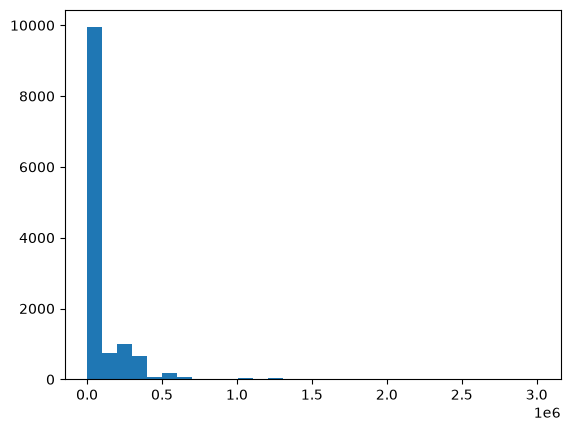

In [55]:
plt.hist(df["price"],bins=30)

In [56]:
import numpy as np

In [57]:
log_price_check=np.log1p(df["price"])

In [58]:
log_price_check.skew()

np.float64(0.6768160262154764)

(array([1.000e+00, 0.000e+00, 1.400e+01, 2.800e+01, 4.500e+01, 1.870e+02,
        3.580e+02, 5.810e+02, 9.940e+02, 1.411e+03, 1.309e+03, 1.329e+03,
        1.194e+03, 8.340e+02, 7.380e+02, 6.140e+02, 4.070e+02, 2.820e+02,
        2.520e+02, 2.940e+02, 8.210e+02, 2.970e+02, 5.000e+02, 1.660e+02,
        3.700e+01, 4.300e+01, 6.200e+01, 3.700e+01, 1.000e+01, 2.000e+00]),
 array([ 7.31388683,  7.56734009,  7.82079334,  8.0742466 ,  8.32769986,
         8.58115311,  8.83460637,  9.08805963,  9.34151288,  9.59496614,
         9.8484194 , 10.10187265, 10.35532591, 10.60877916, 10.86223242,
        11.11568568, 11.36913893, 11.62259219, 11.87604545, 12.1294987 ,
        12.38295196, 12.63640522, 12.88985847, 13.14331173, 13.39676498,
        13.65021824, 13.9036715 , 14.15712475, 14.41057801, 14.66403127,
        14.91748452]),
 <BarContainer object of 30 artists>)

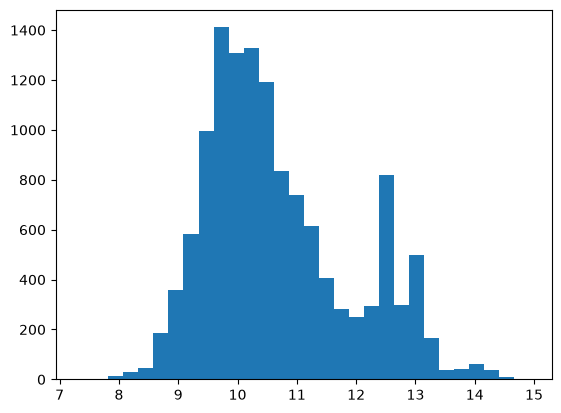

In [59]:
plt.hist(log_price_check,bins=30)

In [60]:
house_size_quantile=df["house_size"].quantile([0.10,.95,0.98,0.99,0.999])

In [61]:
house_size_quantile

0.100     550.000
0.950    5896.000
0.980    6521.000
0.990    6521.000
0.999    7513.706
Name: house_size, dtype: float64

In [62]:
df.nlargest(10,"house_size")[["house_size","price"]]

,house_size,price
4570,14521.0,3010101
3964,11221.0,854612
1631,10000.0,250000
3961,9841.0,1010102
3896,9500.0,850000
7536,9500.0,55000
940,9000.0,1000000
1226,9000.0,1000000
3573,8521.0,1162992
9586,8326.0,600000


(array([2.135e+03, 5.031e+03, 1.974e+03, 1.035e+03, 3.430e+02, 8.250e+02,
        6.300e+01, 5.300e+01, 3.900e+01, 7.900e+01, 5.300e+01, 6.900e+02,
        1.110e+02, 3.570e+02, 4.200e+01, 6.000e+00, 1.000e+00, 2.000e+00,
        2.000e+00, 2.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([  150.        ,   629.03333333,  1108.06666667,  1587.1       ,
         2066.13333333,  2545.16666667,  3024.2       ,  3503.23333333,
         3982.26666667,  4461.3       ,  4940.33333333,  5419.36666667,
         5898.4       ,  6377.43333333,  6856.46666667,  7335.5       ,
         7814.53333333,  8293.56666667,  8772.6       ,  9251.63333333,
         9730.66666667, 10209.7       , 10688.73333333, 11167.76666667,
        11646.8       , 12125.83333333, 12604.86666667, 13083.9       ,
        13562.93333333, 14041.96666667, 14521.        ]),
 <BarContainer object of 30 artists>)

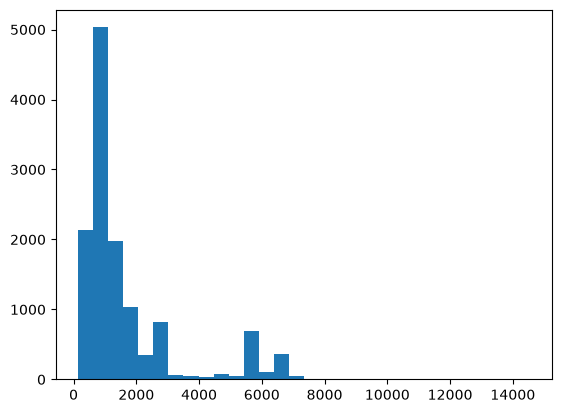

In [63]:
plt.hist(df["house_size"],bins=30)

In [64]:
log_check_house=np.log1p(df["house_size"])

(array([4.900e+01, 4.200e+01, 1.200e+01, 4.900e+01, 7.200e+01, 1.740e+02,
        1.320e+02, 3.840e+02, 6.880e+02, 1.291e+03, 9.330e+02, 1.127e+03,
        1.879e+03, 1.267e+03, 6.740e+02, 7.630e+02, 6.200e+02, 2.090e+02,
        2.750e+02, 7.210e+02, 8.100e+01, 4.600e+01, 1.160e+02, 1.060e+02,
        1.078e+03, 4.800e+01, 5.000e+00, 4.000e+00, 1.000e+00, 1.000e+00]),
 array([5.01727984, 5.16948451, 5.32168918, 5.47389386, 5.62609853,
        5.7783032 , 5.93050787, 6.08271255, 6.23491722, 6.38712189,
        6.53932656, 6.69153124, 6.84373591, 6.99594058, 7.14814526,
        7.30034993, 7.4525546 , 7.60475927, 7.75696395, 7.90916862,
        8.06137329, 8.21357797, 8.36578264, 8.51798731, 8.67019198,
        8.82239666, 8.97460133, 9.126806  , 9.27901067, 9.43121535,
        9.58342002]),
 <BarContainer object of 30 artists>)

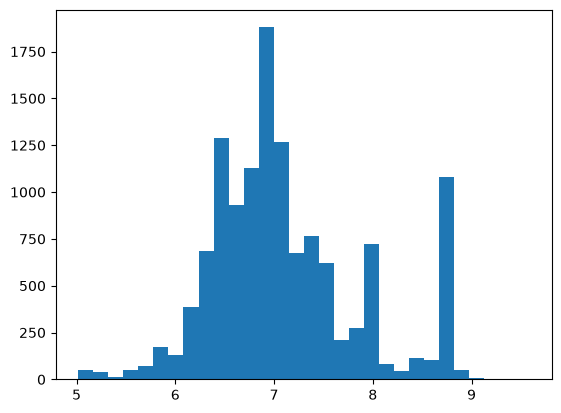

In [65]:
plt.hist(log_check_house,bins=30)

## Data Preprocessing
- Encoding
- StandardScaler
- Train-Test Split

In [66]:
from sklearn.model_selection import train_test_split

In [67]:
x=df.drop(columns="price")
y=np.log1p(df["price"])

In [68]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [69]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [70]:
from sklearn.compose import ColumnTransformer

In [71]:
cat_cols = [
    "location",
    "city",
    "TYPE"
]

In [72]:
num_cols = [
    "house_size",
    "latitude",
    "longitude",
    "numBathrooms",
    "numBalconies",
    "bedrooms"
]

In [73]:
Preprocessor=ColumnTransformer(transformers=[("cat",OneHotEncoder(handle_unknown='ignore',sparse_output=False),cat_cols),
                                            ("num",StandardScaler(),num_cols)])

In [74]:
x_train = Preprocessor.fit_transform(x_train)
x_test = Preprocessor.transform(x_test)

In [75]:
x_train.shape

(10277, 646)

In [76]:
x_train.dtype

dtype('float64')

In [77]:
import torch

## Convert Data to PyTorch Tensors

In [78]:
x_train=torch.tensor(x_train,dtype=torch.float)

In [79]:
x_test=torch.tensor(x_test,dtype=torch.float)

In [80]:
y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [81]:
len(x_train),len(x_test),len(y_train),len(y_test)

(10277, 2570, 10277, 2570)

In [82]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [83]:
print(x_train.shape)

torch.Size([10277, 646])


In [84]:
print(y_train.shape)

torch.Size([10277, 1])


In [85]:
from torch import nn

In [86]:
class HouseRentPrice(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1=nn.Linear(in_features=646,out_features=128)
        self.layer2=nn.Linear(in_features=128,out_features=64)
        self.layer3=nn.Linear(in_features=64,out_features=32)
        self.layer4=nn.Linear(in_features=32,out_features=1)

        self.Relu=nn.ReLU()
    def forward(self,x):
        return self.layer4(self.Relu(self.layer3(self.Relu(self.layer2(self.Relu(self.layer1(x)))))))

In [87]:
modelv0=HouseRentPrice()

In [88]:
modelv0.state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 0.0317,  0.0022, -0.0177,  ..., -0.0282,  0.0149,  0.0330],
                      [ 0.0180, -0.0075, -0.0357,  ...,  0.0032, -0.0052,  0.0222],
                      [ 0.0366, -0.0224,  0.0014,  ...,  0.0230, -0.0162, -0.0076],
                      ...,
                      [-0.0284,  0.0302, -0.0250,  ...,  0.0346, -0.0248, -0.0101],
                      [-0.0031, -0.0380,  0.0326,  ..., -0.0313,  0.0179, -0.0152],
                      [ 0.0146,  0.0252, -0.0051,  ...,  0.0077, -0.0190,  0.0138]])),
             ('layer1.bias',
              tensor([ 3.1576e-02,  1.6444e-02,  2.6966e-02, -1.3203e-02,  2.5895e-03,
                      -1.9907e-02,  2.3785e-02, -1.4222e-02,  2.1506e-02,  2.7939e-02,
                      -1.4159e-02,  3.5191e-02, -7.5248e-03,  2.0397e-02,  1.9159e-02,
                      -2.0142e-02, -6.8778e-03, -1.5583e-02, -2.1091e-02, -5.0499e-03,
                       1.8895e-02, -3.5513e-02, -3.4944e-0

In [89]:
modelv0.to(device)

HouseRentPrice(
  (layer1): Linear(in_features=646, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (layer3): Linear(in_features=64, out_features=32, bias=True)
  (layer4): Linear(in_features=32, out_features=1, bias=True)
  (Relu): ReLU()
)

In [90]:
next(modelv0.parameters()).device

device(type='cuda', index=0)

In [91]:
x_test,y_test

(tensor([[ 0.0000,  0.0000,  0.0000,  ..., -1.3175, -1.3423, -1.2256],
         [ 0.0000,  0.0000,  0.0000,  ..., -1.3175, -1.3423, -1.2256],
         [ 0.0000,  0.0000,  0.0000,  ..., -1.3175,  0.4246, -0.3074],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ..., -0.3139,  0.4246, -0.3074],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.6898,  0.4246,  0.6109],
         [ 0.0000,  0.0000,  0.0000,  ...,  2.6970,  0.4246,  1.5291]]),
 tensor([[11.4616],
         [ 9.9523],
         [10.5967],
         ...,
         [10.0859],
         [11.7361],
         [12.7657]]))

In [92]:
loss_fn=nn.MSELoss()

In [93]:
opt=torch.optim.Adam(modelv0.parameters(),lr=0.01)

In [94]:
x_train,y_train=x_train.to(device),y_train.to(device)
x_test,y_test=x_test.to(device),y_test.to(device)

In [95]:
torch.manual_seed(42)
epochs=1200
for epoch in range(epochs):
    modelv0.train()
    pred=modelv0(x_train)
    loss=loss_fn(y_train,pred)
    opt.zero_grad()
    loss.backward()
    opt.step()
    modelv0.eval()
    with torch.inference_mode():
        test_pred=modelv0(x_test)
        test_loss=loss_fn(y_test,test_pred)
    if epoch%10==0:
        print(f"Epoch :{epoch} | loss : {loss:.4f} | test_loss : {test_loss:.4f}")

Epoch :0 | loss : 120.4517 | test_loss : 118.2145
Epoch :10 | loss : 5.2317 | test_loss : 29.3892
Epoch :20 | loss : 11.2385 | test_loss : 8.8899
Epoch :30 | loss : 0.8202 | test_loss : 1.2888
Epoch :40 | loss : 0.9210 | test_loss : 1.9383
Epoch :50 | loss : 0.6083 | test_loss : 0.8262
Epoch :60 | loss : 0.2639 | test_loss : 0.6539
Epoch :70 | loss : 0.1976 | test_loss : 0.4521
Epoch :80 | loss : 0.1638 | test_loss : 0.3902
Epoch :90 | loss : 0.1242 | test_loss : 0.3229
Epoch :100 | loss : 0.1070 | test_loss : 0.2842
Epoch :110 | loss : 0.0953 | test_loss : 0.2665
Epoch :120 | loss : 0.0881 | test_loss : 0.2578
Epoch :130 | loss : 0.0826 | test_loss : 0.2541
Epoch :140 | loss : 0.0786 | test_loss : 0.2494
Epoch :150 | loss : 0.0755 | test_loss : 0.2476
Epoch :160 | loss : 0.0733 | test_loss : 0.2458
Epoch :170 | loss : 0.0717 | test_loss : 0.2446
Epoch :180 | loss : 0.0704 | test_loss : 0.2435
Epoch :190 | loss : 0.0694 | test_loss : 0.2429
Epoch :200 | loss : 0.0687 | test_loss : 0.24

In [102]:
with torch.inference_mode():
    final_pred=modelv0(x_test)
final_pred

tensor([[11.3545],
        [ 9.8237],
        [10.0605],
        ...,
        [10.0468],
        [11.6104],
        [12.3909]], device='cuda:0')

In [104]:
pred = final_pred.cpu().numpy().flatten()
true = y_test.cpu().numpy().flatten()

In [105]:
def plot_prediction(pred,true):
    plt.figure(figsize=(6,6))
    plt.scatter(true, pred, alpha=0.5)
    plt.xlabel("Actual Log Price")
    plt.ylabel("Predicted Log Price")
    plt.title("Actual vs Predicted")
    plt.plot([true.min(), true.max()],[true.min(), true.max()],"r--")
    plt.show()

## Actual vs Predicted Visualization

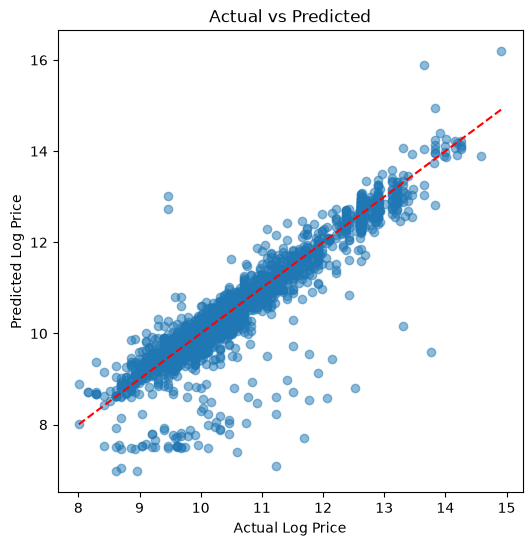

In [107]:
plot_prediction(pred,true)

In [109]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
pred_price = np.expm1(pred)
true_price = np.expm1(true)

print("MAE :", mean_absolute_error(true, pred))
print("RMSE:", np.sqrt(mean_squared_error(true, pred)))
print("R²  :", r2_score(true, pred))

MAE : 0.26134705543518066
RMSE: 0.4815130282864701
R²  : 0.8464957475662231
